IDEAS:

- use a better dataset (no roads / man-made structures)
- use a diverse dataset (rivers, smaller-scale roughness, etc.)
- erode result for realism

In [549]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torchvision.transforms as transforms
from torchvision.models import vgg19, VGG19_Weights

import copy

In [550]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

In [551]:
torch.manual_seed(67)

In [552]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [553]:
def gaussian_kernel(size: int, sigma: float):
    ax = torch.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = torch.meshgrid(ax, ax, indexing="ij")
    kernel = torch.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    kernel = kernel / kernel.sum()
    return kernel

def gaussian_blur(img: torch.Tensor, blur_size: int, sigma: float):
    # img shape: (batch, channels, H, W)
    kernel = gaussian_kernel(blur_size, sigma)
    kernel = kernel.expand(img.size(1), 1, blur_size, blur_size)
    return F.conv2d(img, kernel, padding=blur_size//2, groups=img.size(1))

In [554]:
# desired size of the output image
imsize = 512 if torch.cuda.is_available() else 128  # smaller if no GPU

loader = transforms.Compose([
    transforms.Resize(imsize),
    transforms.ToTensor()
])

def image_loader(image_name):
    image = Image.open(image_name)
    image = loader(image).unsqueeze(0)  # add batch dimension
    return image.to(device, torch.float)

# adjust paths to your MyDrive
styles = 10
style_imgs = []
for i in range(1, styles+1):
    style_imgs.append(image_loader(f"/content/drive/MyDrive/Images/style{i}.jpg"))

content_img = image_loader("/content/drive/MyDrive/Images/other4.jpg")

content_img = content_img.mean(dim=1, keepdim=True).repeat(1, 3, 1, 1)  # forcibly turn to non-b&w

for style_img in style_imgs:
  assert style_img.size() == content_img.size(), \
    f"we need to import style and content images of the same size: {style_img.size()} != {content_img.size()}"

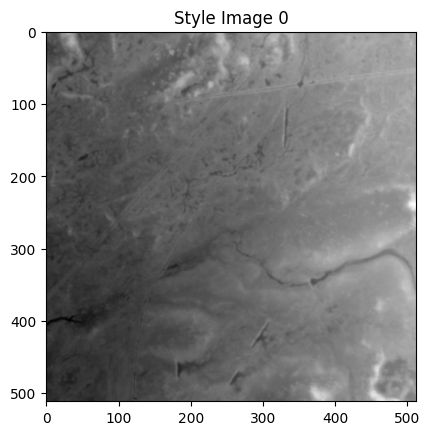

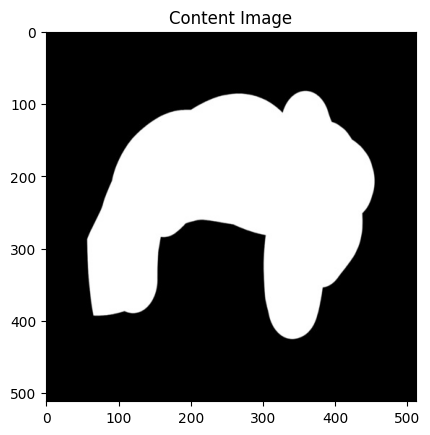

In [555]:
unloader = transforms.ToPILImage()  # reconvert into PIL image

plt.ion()

def imshow(tensor, title=None):
    image = tensor.cpu().clone()  # we clone the tensor to not do changes on it
    image = image.squeeze(0)      # remove the fake batch dimension
    image = unloader(image)
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.pause(0.001) # pause a bit so that plots are updated


plt.figure()
imshow(style_imgs[0], title='Style Image 0')

plt.figure()
imshow(content_img, title='Content Image')

In [556]:
class ContentLoss(nn.Module):

    def __init__(self, target, p=2):
        super(ContentLoss, self).__init__()
        self.target = target.detach()
        self.p = p

    def forward(self, input):
        diff = input - self.target
        self.loss = torch.mean((torch.abs(diff)*(self.target + 0.1))) ** self.p
        return input

In [557]:
def gram_matrix(input):
    a, b, c, d = input.size()  # a=batch size(=1)
    # b=number of feature maps
    # (c,d)=dimensions of a f. map (N=c*d)

    features = input.view(a * b, c * d)  # resize F_XL into \hat F_XL

    G = torch.mm(features, features.t())  # compute the gram product

    # we 'normalize' the values of the gram matrix
    # by dividing by the number of element in each feature maps.
    return G.div(a * b * c * d)

In [558]:
class StyleLoss(nn.Module):
    def __init__(self, target_features):
        super(StyleLoss, self).__init__()
        # target_features is a list of feature tensors (one per style image)
        self.targets = [gram_matrix(t.detach()) for t in target_features]
        self.weights = [1.0 / len(target_features)] * len(target_features)

    def forward(self, input):
        G = gram_matrix(input)
        # weighted sum of losses over all target style images
        self.loss = sum(F.mse_loss(G, target) * w for target, w in zip(self.targets, self.weights))
        return input

In [559]:
cnn = vgg19(weights=VGG19_Weights.DEFAULT).features.eval()

In [560]:
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406])
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225])

# create a module to normalize input image so we can easily put it in a
# ``nn.Sequential``
class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        # .view the mean and std to make them [C x 1 x 1] so that they can
        # directly work with image Tensor of shape [B x C x H x W].
        # B is batch size. C is number of channels. H is height and W is width.
        self.mean = torch.tensor(mean).view(-1, 1, 1)
        self.std = torch.tensor(std).view(-1, 1, 1)

    def forward(self, img):
        # normalize ``img``
        return (img - self.mean) / self.std

In [561]:
# desired depth layers to compute style/content losses :
content_layers_default = ['conv_4']
style_layers_default = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

def get_style_model_and_losses(cnn, normalization_mean, normalization_std,
                               style_imgs, content_img,
                               content_layers=content_layers_default,
                               style_layers=style_layers_default):
    # normalization module
    normalization = Normalization(normalization_mean, normalization_std)

    # just in order to have an iterable access to or list of content/style
    # losses
    content_losses = []
    style_losses = []

    # assuming that ``cnn`` is a ``nn.Sequential``, so we make a new ``nn.Sequential``
    # to put in modules that are supposed to be activated sequentially
    model = nn.Sequential(normalization)

    i = 0  # increment every time we see a conv
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = 'conv_{}'.format(i)
        elif isinstance(layer, nn.ReLU):
            name = 'relu_{}'.format(i)
            # The in-place version doesn't play very nicely with the ``ContentLoss``
            # and ``StyleLoss`` we insert below. So we replace with out-of-place
            # ones here.
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = 'pool_{}'.format(i)
        elif isinstance(layer, nn.BatchNorm2d):
            name = 'bn_{}'.format(i)
        else:
            raise RuntimeError('Unrecognized layer: {}'.format(layer.__class__.__name__))

        model.add_module(name, layer)

        if name in content_layers:
            # add content loss:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module("content_loss_{}".format(i), content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            # compute target features for all style images
            target_features = [model(style_img).detach() for style_img in style_imgs]
            # create a single StyleLoss module that averages all targets
            style_loss = StyleLoss(target_features)
            model.add_module("style_loss_{}".format(i), style_loss)
            style_losses.append(style_loss)

    # now we trim off the layers after the last content and style losses
    for i in range(len(model) - 1, -1, -1):
        if isinstance(model[i], ContentLoss) or isinstance(model[i], StyleLoss):
            break

    model = model[:(i + 1)]

    return model, style_losses, content_losses

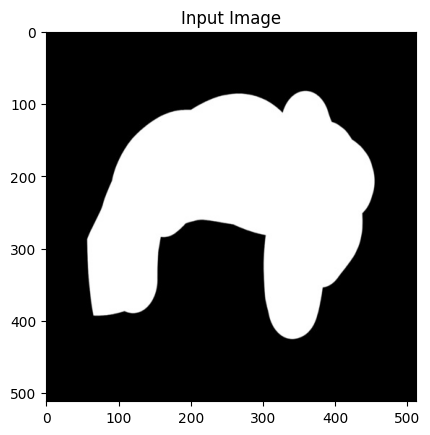

In [562]:
input_img = content_img.clone()
# if you want to use white noise by using the following code:
#
# .. code-block:: python
#
#    input_img = torch.randn(content_img.data.size())

# add the original input image to the figure:
plt.figure()
imshow(input_img, title='Input Image')

In [563]:
print(input_img)

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]], device='cuda:0')


In [564]:
def total_variation_loss(img):
    # img shape: (1,1,H,W) or (1,3,H,W)
    # assume pixel values in [0,1]

    # vertical diffs
    diff_h = img[:, :, 1:, :] - img[:, :, :-1, :]
    brightness_h = torch.mean(torch.stack([img[:, :, 1:, :], img[:, :, :-1, :]]), dim=0)
    weight_h = 1.2
    tv_h = ((diff_h ** 2) * weight_h).sum()

    # horizontal diffs
    diff_w = img[:, :, :, 1:] - img[:, :, :, :-1]
    brightness_w = torch.mean(torch.stack([img[:, :, :, 1:], img[:, :, :, :-1]]), dim=0)
    weight_w = 1.2
    tv_w = ((diff_w ** 2) * weight_w).sum()

    return tv_h + tv_w


In [565]:
def get_input_optimizer(input_img):
    # this line to show that input is a parameter that requires a gradient
    optimizer = optim.LBFGS([input_img])
    return optimizer

In [566]:
def run_style_transfer(cnn, normalization_mean, normalization_std,
                       content_img, style_imgs, input_img, num_steps=600,
                       style_weight=1.02542, content_weight=1.04913, tv_weight=0.12):
    """Run the style transfer."""
    print('Building the style transfer model..')
    model, style_losses, content_losses = get_style_model_and_losses(cnn,
        normalization_mean, normalization_std, style_imgs, content_img)

    # We want to optimize the input and not the model parameters so we
    # update all the requires_grad fields accordingly
    input_img.requires_grad_(True)
    # We also put the model in evaluation mode, so that specific layers
    # such as dropout or batch normalization layers behave correctly.
    model.eval()
    model.requires_grad_(False)

    optimizer = get_input_optimizer(input_img)

    print('Optimizing..')
    run = [0]
    while run[0] <= num_steps:

        def closure():
            # correct the values of updated input image
            with torch.no_grad():
                input_img.clamp_(0, 1)

            optimizer.zero_grad()
            model(input_img)
            style_score = 0
            content_score = 0

            for sl in style_losses:
                style_score += sl.loss
            for cl in content_losses:
                content_score += cl.loss

            style_score *= style_weight
            content_score *= content_weight
            tv_loss = tv_weight * total_variation_loss(input_img)

            loss = style_score + content_score + tv_loss
            loss.backward()

            run[0] += 1
            if run[0] % 50 == 0:
                print("run {}:".format(run))
                print('Style Loss : {:4f} Content Loss: {:4f} TV Loss: {:4f}'.format(
                    style_score.item(), content_score.item(), tv_loss))
                print()

            return style_score + content_score + tv_loss # return total loss for optimizer

        optimizer.step(closure)

    # a last correction...
    with torch.no_grad():
        input_img.clamp_(0, 1)

    input_img = input_img.mean(dim=1, keepdim=True)

    return input_img

In [567]:
!pip install pygad

In [568]:
"""import pygad

def run_style_transfer_eval(cnn, normalization_mean, normalization_std,
                            content_img, style_imgs, input_img,
                            num_steps=200, style_weight=1e6, content_weight=1e1, tv_weight=1.5e-2):
    model, style_losses, content_losses = get_style_model_and_losses(
        cnn, normalization_mean, normalization_std, style_imgs, content_img)

    input_img = input_img.clone().detach()
    input_img.requires_grad_(True)
    model.eval()
    model.requires_grad_(False)

    optimizer = get_input_optimizer(input_img)

    run = [0]
    while run[0] <= num_steps:
        def closure():
            with torch.no_grad():
                input_img.clamp_(0, 1)
            optimizer.zero_grad()
            model(input_img)

            style_score = sum([sl.loss for sl in style_losses])
            content_score = sum([cl.loss for cl in content_losses])

            style_score = style_score * style_weight
            content_score = content_score * content_weight
            tv_loss = tv_weight * total_variation_loss(input_img)

            loss = style_score + content_score + tv_loss
            loss.backward()
            run[0] += 1
            return loss

        optimizer.step(closure)

    with torch.no_grad():
        input_img.clamp_(0, 1)

    model(input_img)
    style_score = sum([sl.loss for sl in style_losses]).item() * style_weight
    content_score = sum([cl.loss for cl in content_losses]).item() * content_weight
    tv_loss = (tv_weight * total_variation_loss(input_img)).item()
    return style_score, content_score, tv_loss


# fitness function must take 3 args now
def fitness_func(ga_instance, solution, solution_idx):
    log_style, log_content, log_tv = solution
    style_w = 10.0 ** log_style
    content_w = 10.0 ** log_content
    tv_w = 10.0 ** log_tv

    s, c, tv = run_style_transfer_eval(
        cnn, cnn_normalization_mean, cnn_normalization_std,
        content_img, style_imgs, input_img.clone().detach(),
        num_steps=150,  # shorten for speed
        style_weight=style_w,
        content_weight=content_w,
        tv_weight=tv_w
    )
    total_loss = s + c + tv
    print(f"Fitness: {total_loss}")
    return -total_loss  # maximize fitness = minimize loss


gene_space = [
    {'low': -2.0, 'high': 8.0},   # log10 style
    {'low': -2.0, 'high': 4.0},   # log10 content
    {'low': -6.0, 'high': 0.0}    # log10 tv
]

ga = pygad.GA(
    num_generations=10,
    num_parents_mating=4,
    sol_per_pop=6,
    num_genes=3,
    gene_space=gene_space,
    fitness_func=fitness_func,
    parent_selection_type="sss",
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=20,
    keep_parents=2
)

ga.run()

solution, solution_fitness, solution_idx = ga.best_solution()
best_style_w = 10.0 ** solution[0]
best_content_w = 10.0 ** solution[1]
best_tv_w = 10.0 ** solution[2]

print("Best weights:", best_style_w, best_content_w, best_tv_w)
print("Best fitness:", solution_fitness)"""


'import pygad\n\ndef run_style_transfer_eval(cnn, normalization_mean, normalization_std,\n                            content_img, style_imgs, input_img,\n                            num_steps=200, style_weight=1e6, content_weight=1e1, tv_weight=1.5e-2):\n    model, style_losses, content_losses = get_style_model_and_losses(\n        cnn, normalization_mean, normalization_std, style_imgs, content_img)\n\n    input_img = input_img.clone().detach()\n    input_img.requires_grad_(True)\n    model.eval()\n    model.requires_grad_(False)\n\n    optimizer = get_input_optimizer(input_img)\n\n    run = [0]\n    while run[0] <= num_steps:\n        def closure():\n            with torch.no_grad():\n                input_img.clamp_(0, 1)\n            optimizer.zero_grad()\n            model(input_img)\n\n            style_score = sum([sl.loss for sl in style_losses])\n            content_score = sum([cl.loss for cl in content_losses])\n\n            style_score = style_score * style_weight\n       

In [569]:
output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std,
                            content_img, style_imgs, input_img)  # training loop

Building the style transfer model..
Optimizing..
run [50]:
Style Loss : 0.000857 Content Loss: 7.750225 TV Loss: 23.371161

run [100]:
Style Loss : 0.000774 Content Loss: 8.291526 TV Loss: 15.932585

run [150]:
Style Loss : 0.000712 Content Loss: 8.673589 TV Loss: 12.700594

run [200]:
Style Loss : 0.000658 Content Loss: 8.961349 TV Loss: 10.844450

run [250]:
Style Loss : 0.000611 Content Loss: 9.152755 TV Loss: 9.635136

run [300]:
Style Loss : 0.000571 Content Loss: 9.334449 TV Loss: 8.735841

run [350]:
Style Loss : 0.000535 Content Loss: 9.469516 TV Loss: 8.022969

run [400]:
Style Loss : 0.000504 Content Loss: 9.571517 TV Loss: 7.430388

run [450]:
Style Loss : 0.000481 Content Loss: 9.651436 TV Loss: 6.902323

run [500]:
Style Loss : 0.000468 Content Loss: 9.667513 TV Loss: 6.445819

run [550]:
Style Loss : 0.000473 Content Loss: 9.639951 TV Loss: 6.053927

run [600]:
Style Loss : 0.000501 Content Loss: 9.580639 TV Loss: 5.712098



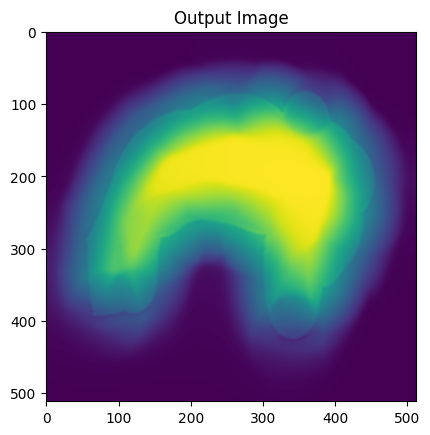

In [570]:
plt.figure()
imshow(output, title='Output Image')

# sphinx_gallery_thumbnail_number = 4
plt.ioff()
plt.show()

In [571]:
# Tune SCALING_FACTOR

min = np.inf
index = 0
for i in range(0, 3000):
  r0 = output ** (i/1000)

  result = gaussian_blur(r0, BLUR_SIZE, sigma)  # smoothen
  content_loss = (torch.mean((torch.abs((input_img - result))*(input_img + 0.1))) ** 2).item()
  if content_loss < min:
    min = content_loss
    index = i/1000

  print("Content loss:", content_loss)

print(f"Minimum content loss: {min}")
print(f"Index: {index}")

Content loss: 0.028408575803041458
Content loss: 0.028264157474040985
Content loss: 0.02812056429684162
Content loss: 0.02797780930995941
Content loss: 0.027835899963974953
Content loss: 0.027694812044501305
Content loss: 0.027554558590054512
Content loss: 0.02741512469947338
Content loss: 0.027276501059532166
Content loss: 0.027138691395521164
Content loss: 0.02700168639421463
Content loss: 0.02686547301709652
Content loss: 0.026730051264166832
Content loss: 0.02659541927278042
Content loss: 0.026461567729711533
Content loss: 0.026328489184379578
Content loss: 0.026196176186203957
Content loss: 0.026064634323120117
Content loss: 0.025933844968676567
Content loss: 0.02580382116138935
Content loss: 0.02567453496158123
Content loss: 0.0255460012704134
Content loss: 0.025418194010853767
Content loss: 0.02529112994670868
Content loss: 0.025164786726236343
Content loss: 0.02503916807472706
Content loss: 0.024914273992180824
Content loss: 0.02479008585214615
Content loss: 0.02466661110520363

Content loss: 4.825350060855271e-06


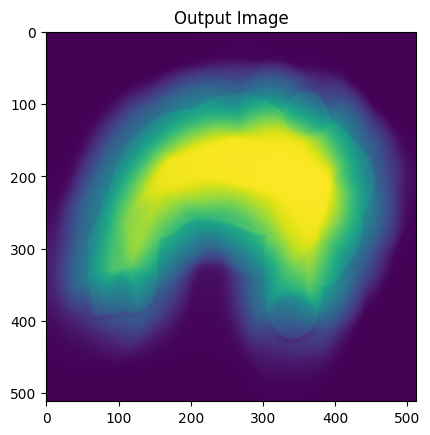

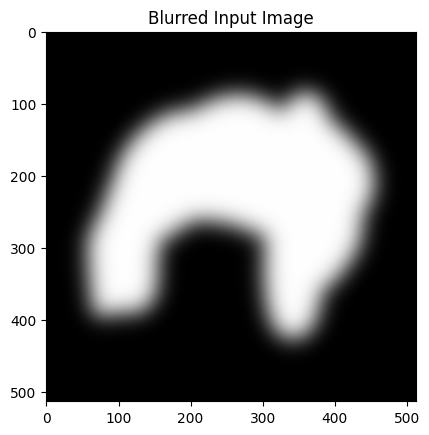

In [572]:
# Scale the "unpassable" part of the output (white mask)
# Here, the input image itself is a mask because "passable" regions are 0, "unpassable" are 1

input_img = input_img.mean(dim=1, keepdim=True)  # forcibly turn to b&w

BLUR_SIZE = 5
sigma = 1.0
SCALING_FACTOR = index

r0 = output ** SCALING_FACTOR

result = gaussian_blur(r0, BLUR_SIZE, sigma)  # smoothen

content_loss = (torch.mean((torch.abs((input_img - result))*(input_img + 0.1))) ** 2).item()

blurred_img = gaussian_blur(content_img, 400, 15.0)

print("Content loss:", content_loss)

plt.figure()
imshow(result, title='Output Image')

plt.ioff()
plt.show()

plt.figure()
imshow(blurred_img, title='Blurred Input Image')

plt.ioff()
plt.show()

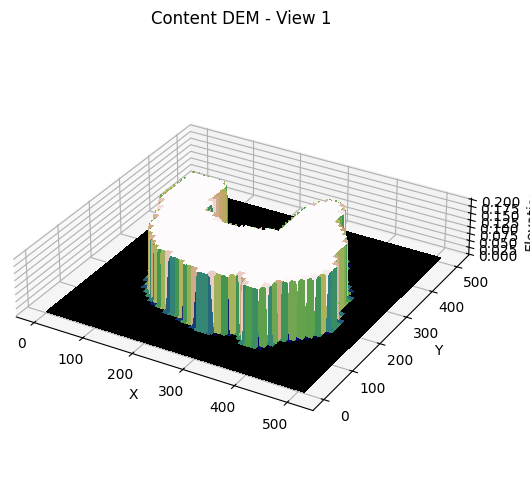

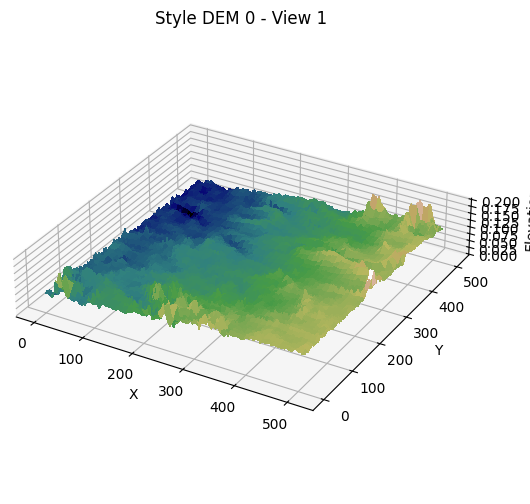

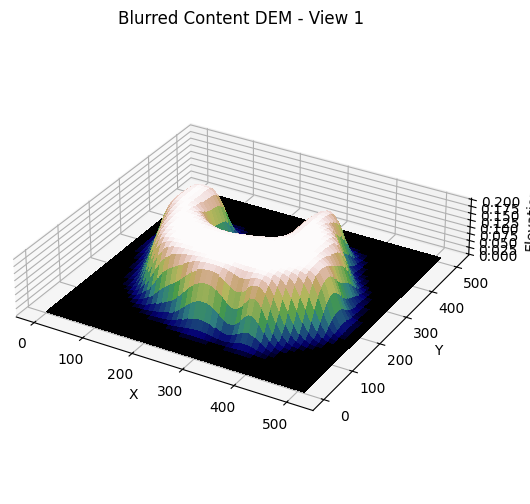

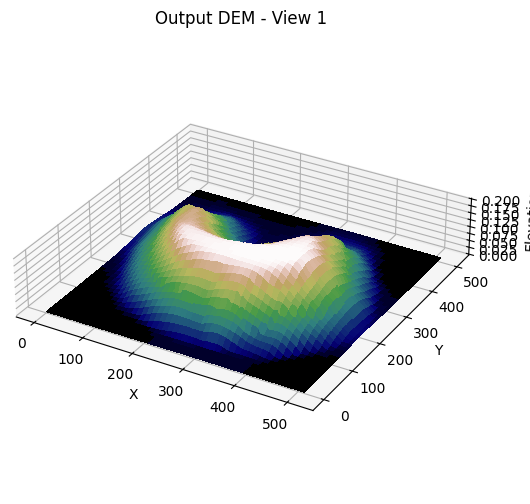

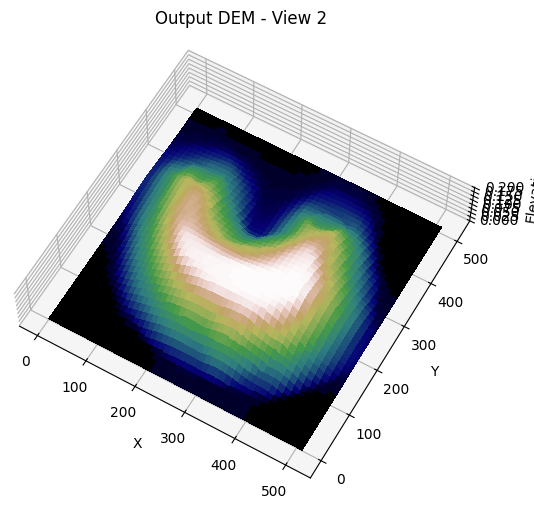

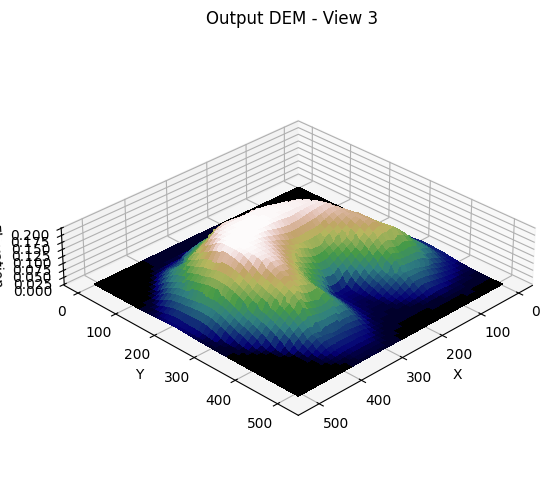

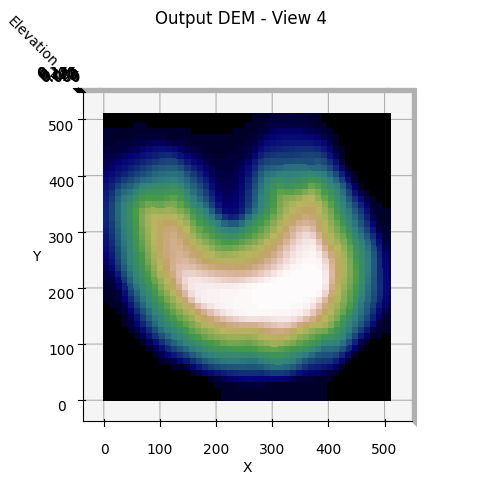

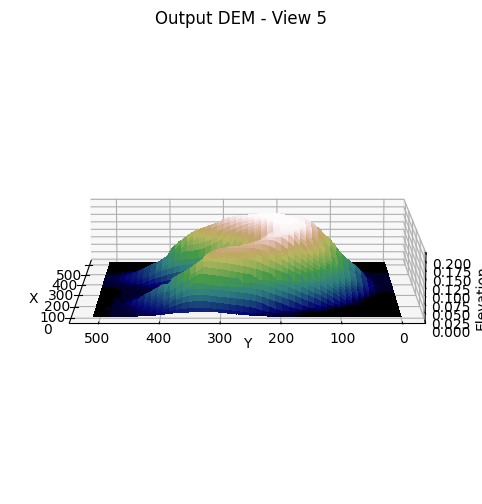

In [573]:
def tensor_to_array(img):
    if isinstance(img, torch.Tensor):
        img = img.detach().cpu().clone().squeeze(0)
        if img.shape[0] == 3:  # RGB
            img = img.mean(0)  # convert to grayscale
        else:
            img = img.squeeze(0)
        return img.numpy()
    return img

def plot_surface_views(img, title="DEM", zscale=1.0, views=None):
    arr = tensor_to_array(img)
    x = np.arange(arr.shape[1])
    y = np.arange(arr.shape[0])
    X, Y = np.meshgrid(x, y)

    Z = arr * zscale

    if views is None:
        # (elev, azim) pairs
        views = [(30, -60), (60, -60), (30, 45), (90, -90), (10, 180)]

    for i, (elev, azim) in enumerate(views):
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection="3d")

        ax.plot_surface(X, Y, Z, cmap="gist_earth", linewidth=0, antialiased=False)

        ax.set_title(f"{title} - View {i+1}")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Elevation")

        ax.set_box_aspect((1, 1, zscale))  # scale Z axis
        ax.view_init(elev=elev, azim=azim) # set camera angle

        plt.show()


# Plot DEMs
plot_surface_views(content_img, "Content DEM", zscale=0.2, views=[(30, -60)])
plot_surface_views(style_imgs[0], "Style DEM 0", zscale=0.2, views=[(30, -60)])
plot_surface_views(blurred_img, "Blurred Content DEM", zscale=0.2, views=[(30, -60)])
plot_surface_views(output, "Output DEM", zscale=0.2)

In [574]:
# Convert tensor to PIL and save
unloader = transforms.ToPILImage()
image = output.cpu().clone().squeeze(0)  # remove batch dim
image = unloader(image)
save_path = "/content/drive/MyDrive/Images/output.png"
image.save(save_path)
print(f"Saved result to {save_path}")

Saved result to /content/drive/MyDrive/Images/output.png
